# Healthcare Claims Denial Analysis — Exploratory Data Analysis

## 1. Executive Summary

Analysis of **50,000 synthetic healthcare claims** (2022–2024) modeled on real 837/835 EDI patterns.

**Key findings:**
- Overall denial rate is **~26%**, putting **~$78M of billed revenue at risk** over three years.
- **Prior authorization is the #1 controllable driver**: claims requiring auth that didn't obtain it deny at **~84%**, vs ~27% when auth was obtained.
- **Payer mix matters**: self-pay (~40%) and Medicaid (~35%) deny at more than double the Medicare rate (~15%).
- **Coding mismatches** (ICD-10/CPT inconsistency) concentrate in CO-4 and CO-11 — together over half of all denials.
- Denial rates are **stable month-over-month**, meaning the losses are systemic process failures, not seasonal spikes — and therefore fixable.

> All data is synthetic — no PHI/PII. Generated by `scripts/generate_synthetic_data.py`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Professional styling used by every chart in this notebook
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.titleweight'] = 'bold'

df = pd.read_csv('../data/synthetic/claims_50k.csv', parse_dates=['claim_date', 'service_date'])
df['year_month'] = df['claim_date'].dt.to_period('M').astype(str)
df['claim_year'] = df['claim_date'].dt.year
print(f'Loaded {len(df):,} claims, {df.shape[1]} columns')

Loaded 50,000 claims, 26 columns


## 2. Data Overview
Shape, types, missing values, and distribution statistics.

In [2]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)
print('\nMissing values (denial fields are empty for non-denied claims by design):')
print(df.isna().sum()[df.isna().sum() > 0])

Shape: (50000, 26)

Dtypes:
claim_id                                str
patient_id                              str
provider_id                             str
payer_id                                str
claim_date                   datetime64[us]
service_date                 datetime64[us]
icd10_primary                           str
icd10_description                       str
cpt_code                              int64
cpt_description                         str
claim_amount                        float64
allowed_amount                      float64
paid_amount                         float64
claim_status                            str
denial_reason_code                      str
denial_reason_description               str
provider_type                           str
payer_type                              str
patient_age_bucket                      str
state                                   str
prior_auth_required                    bool
prior_auth_obtained                    bool
deni

In [3]:
df.describe(include='number').T.round(2)

,count,mean,std,min,25%,50%,75%,max
cpt_code,50000.0,77758.78,24678.60,27130.0,64483.00,90837.00,99214.00,99291.00
claim_amount,50000.0,3253.92,9593.35,8.0,114.81,209.04,1548.93,74967.32
allowed_amount,50000.0,1400.07,5904.21,0.0,0.00,98.28,212.74,66617.54
paid_amount,50000.0,1122.96,4754.94,0.0,0.00,78.10,170.31,59437.34
denial_flag,50000.0,0.26,0.44,0.0,0.00,0.00,1.00,1.00
place_of_service,50000.0,17.93,6.22,11.0,11.00,21.00,22.00,31.00
claim_year,50000.0,2023.00,0.82,2022.0,2022.00,2023.00,2024.00,2024.00


## 3. Denial Rate Overview

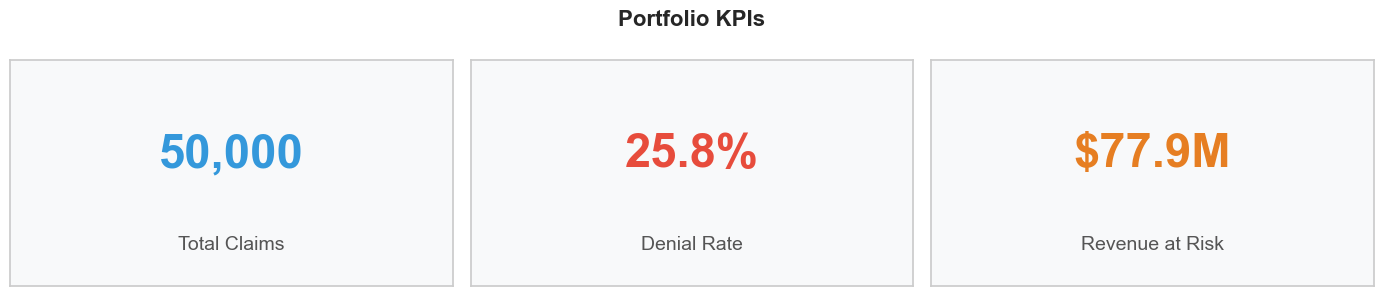

In [4]:
total_claims = len(df)
denial_rate = df['denial_flag'].mean()
revenue_at_risk = df.loc[df['denial_flag'] == 1, 'claim_amount'].sum()

# Big-number cards
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
cards = [
    (f'{total_claims:,}', 'Total Claims', '#3498db'),
    (f'{denial_rate:.1%}', 'Denial Rate', '#e74c3c'),
    (f'${revenue_at_risk/1e6:.1f}M', 'Revenue at Risk', '#e67e22'),
]
for ax, (value, label, color) in zip(axes, cards):
    ax.text(0.5, 0.58, value, ha='center', va='center', fontsize=34, fontweight='bold', color=color)
    ax.text(0.5, 0.18, label, ha='center', va='center', fontsize=14, color='#555')
    ax.set_facecolor('#f8f9fa')
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Portfolio KPIs', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

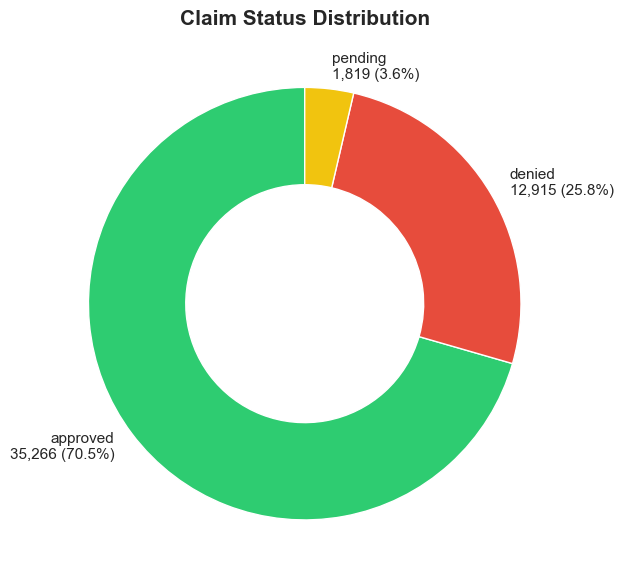

In [5]:
# Claim status distribution
status_counts = df['claim_status'].value_counts()
fig, ax = plt.subplots(figsize=(8, 6))
colors = {'approved': '#2ecc71', 'denied': '#e74c3c', 'pending': '#f1c40f'}
ax.pie(status_counts, labels=[f'{s}\n{c:,} ({c/total_claims:.1%})' for s, c in status_counts.items()],
       colors=[colors[s] for s in status_counts.index],
       startangle=90, wedgeprops=dict(width=0.45, edgecolor='white'))
ax.set_title('Claim Status Distribution')
plt.tight_layout()
plt.show()

## 4. Denial Rate by Payer Type
Color coding: red >30%, orange 20–30%, green <20%.

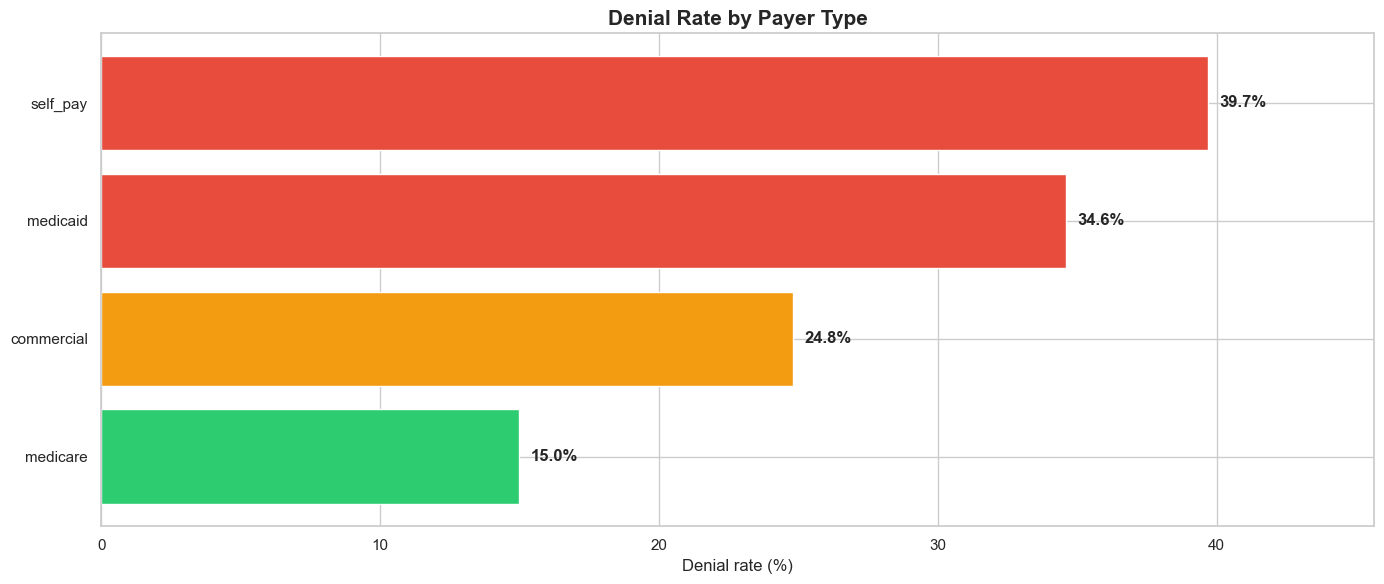

In [6]:
def rate_color(r):
    return '#e74c3c' if r > 0.30 else ('#f39c12' if r > 0.20 else '#2ecc71')

payer_rates = df.groupby('payer_type')['denial_flag'].mean().sort_values()
fig, ax = plt.subplots()
bars = ax.barh(payer_rates.index, payer_rates.values * 100,
               color=[rate_color(r) for r in payer_rates.values])
for bar, r in zip(bars, payer_rates.values):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2, f'{r:.1%}',
            va='center', fontweight='bold')
ax.set_title('Denial Rate by Payer Type')
ax.set_xlabel('Denial rate (%)')
ax.set_xlim(0, payer_rates.max() * 115)
plt.tight_layout()
plt.show()

## 5. Denial Rate by Provider Type

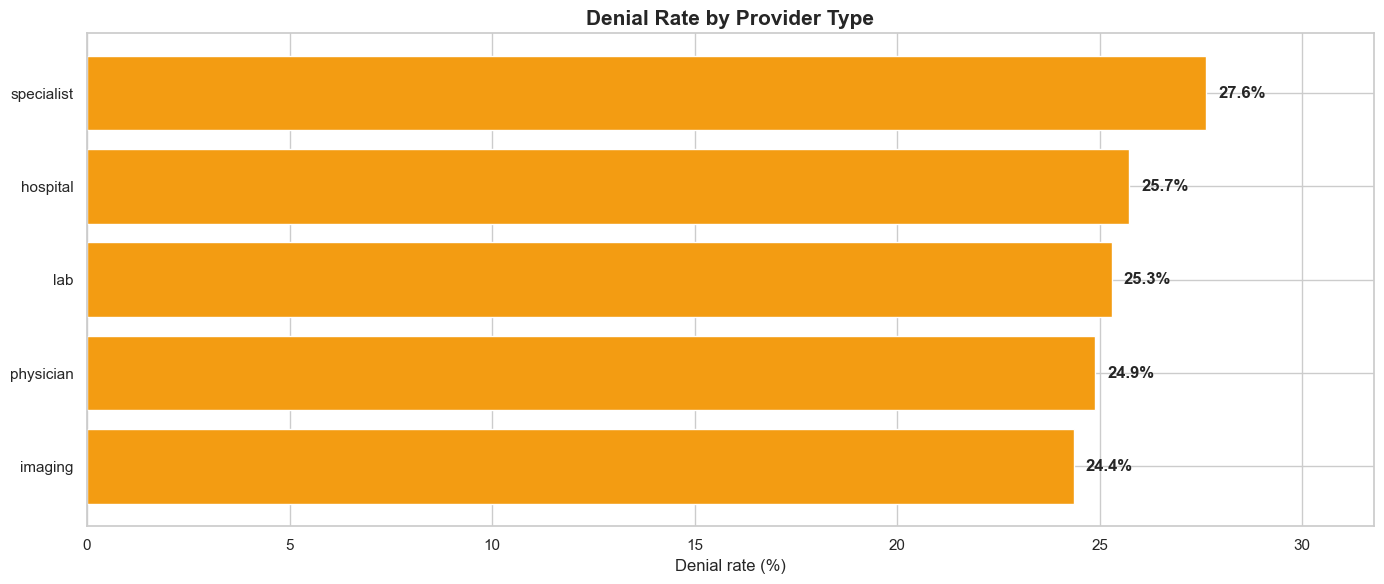

In [7]:
prov_rates = df.groupby('provider_type')['denial_flag'].mean().sort_values()
fig, ax = plt.subplots()
bars = ax.barh(prov_rates.index, prov_rates.values * 100,
               color=[rate_color(r) for r in prov_rates.values])
for bar, r in zip(bars, prov_rates.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{r:.1%}',
            va='center', fontweight='bold')
ax.set_title('Denial Rate by Provider Type')
ax.set_xlabel('Denial rate (%)')
ax.set_xlim(0, prov_rates.max() * 115)
plt.tight_layout()
plt.show()

## 6. Top 10 Denial Reason Codes

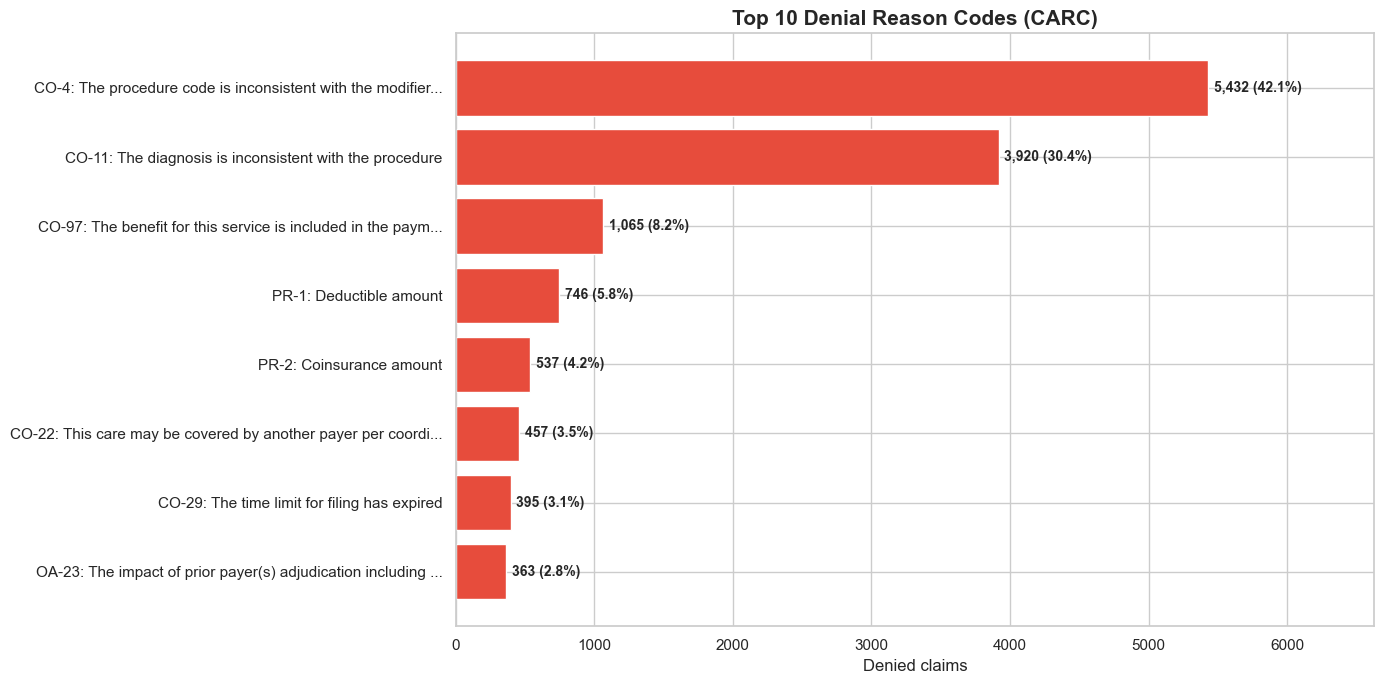

In [8]:
denied = df[df['denial_flag'] == 1]
reason_counts = denied['denial_reason_code'].value_counts().head(10)
desc_map = denied.groupby('denial_reason_code')['denial_reason_description'].first()
labels = [f"{code}: {desc_map[code][:52]}..." if len(desc_map[code]) > 52
          else f"{code}: {desc_map[code]}" for code in reason_counts.index]

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(labels[::-1], reason_counts.values[::-1], color='#e74c3c')
for bar, cnt in zip(bars, reason_counts.values[::-1]):
    pct = cnt / len(denied)
    ax.text(bar.get_width() + 40, bar.get_y() + bar.get_height()/2,
            f'{cnt:,} ({pct:.1%})', va='center', fontweight='bold', fontsize=10)
ax.set_title('Top 10 Denial Reason Codes (CARC)')
ax.set_xlabel('Denied claims')
ax.set_xlim(0, reason_counts.max() * 1.22)
plt.tight_layout()
plt.show()

## 7. Prior Authorization Impact
The most dramatic correlation in the dataset.

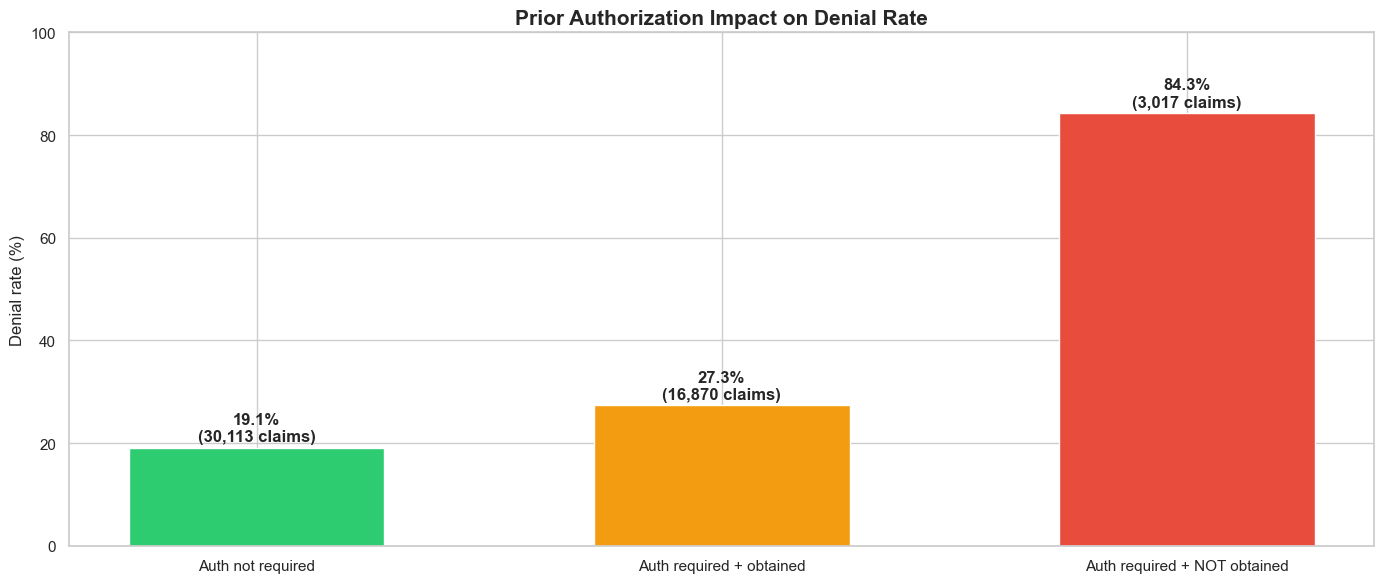

Missing prior auth multiplies denial risk by 3.1x vs auth obtained.


In [9]:
seg = pd.DataFrame({
    'segment': ['Auth not required', 'Auth required + obtained', 'Auth required + NOT obtained'],
    'denial_rate': [
        df.loc[~df['prior_auth_required'], 'denial_flag'].mean(),
        df.loc[df['prior_auth_required'] & df['prior_auth_obtained'], 'denial_flag'].mean(),
        df.loc[df['prior_auth_required'] & ~df['prior_auth_obtained'], 'denial_flag'].mean(),
    ],
    'claims': [
        (~df['prior_auth_required']).sum(),
        (df['prior_auth_required'] & df['prior_auth_obtained']).sum(),
        (df['prior_auth_required'] & ~df['prior_auth_obtained']).sum(),
    ],
})
fig, ax = plt.subplots()
bars = ax.bar(seg['segment'], seg['denial_rate'] * 100,
              color=['#2ecc71', '#f39c12', '#e74c3c'], width=0.55)
for bar, r, n in zip(bars, seg['denial_rate'], seg['claims']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.2,
            f'{r:.1%}\n({n:,} claims)', ha='center', fontweight='bold')
ax.set_title('Prior Authorization Impact on Denial Rate')
ax.set_ylabel('Denial rate (%)')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

print(f"Missing prior auth multiplies denial risk by "
      f"{seg['denial_rate'][2] / seg['denial_rate'][1]:.1f}x vs auth obtained.")

## 8. ICD-10 Analysis
Denial rate by ICD-10 chapter (first letter ≈ disease family) and top diagnoses by volume.

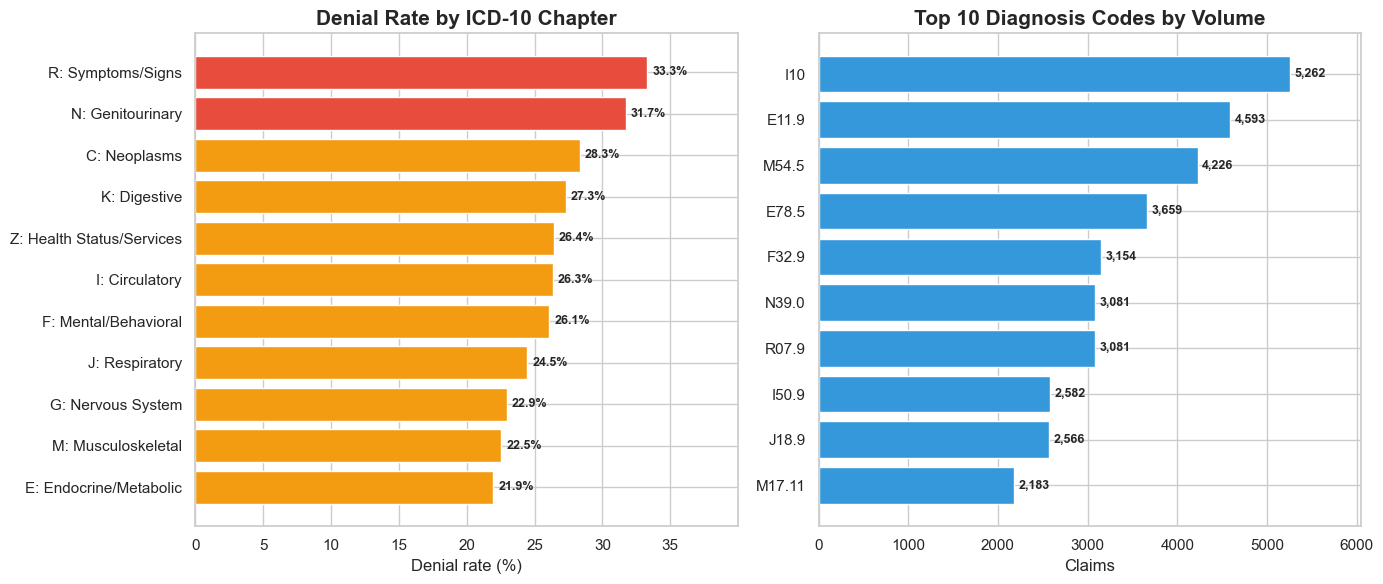

In [10]:
ICD_CHAPTERS = {
    'C': 'C: Neoplasms', 'E': 'E: Endocrine/Metabolic', 'F': 'F: Mental/Behavioral',
    'G': 'G: Nervous System', 'I': 'I: Circulatory', 'J': 'J: Respiratory',
    'K': 'K: Digestive', 'M': 'M: Musculoskeletal', 'N': 'N: Genitourinary',
    'R': 'R: Symptoms/Signs', 'Z': 'Z: Health Status/Services',
}
df['icd10_chapter'] = df['icd10_primary'].str[0].map(ICD_CHAPTERS)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
chapter_rates = df.groupby('icd10_chapter')['denial_flag'].mean().sort_values()
axes[0].barh(chapter_rates.index, chapter_rates.values * 100,
             color=[rate_color(r) for r in chapter_rates.values])
for i, r in enumerate(chapter_rates.values):
    axes[0].text(r * 100 + 0.4, i, f'{r:.1%}', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Denial Rate by ICD-10 Chapter')
axes[0].set_xlabel('Denial rate (%)')
axes[0].set_xlim(0, chapter_rates.max() * 120)

top_dx = df['icd10_primary'].value_counts().head(10)
axes[1].barh(top_dx.index[::-1], top_dx.values[::-1], color='#3498db')
for i, v in enumerate(top_dx.values[::-1]):
    axes[1].text(v + 50, i, f'{v:,}', va='center', fontsize=9, fontweight='bold')
axes[1].set_title('Top 10 Diagnosis Codes by Volume')
axes[1].set_xlabel('Claims')
axes[1].set_xlim(0, top_dx.max() * 1.15)
plt.tight_layout()
plt.show()

## 9. Monthly Denial Trends (2022–2024)

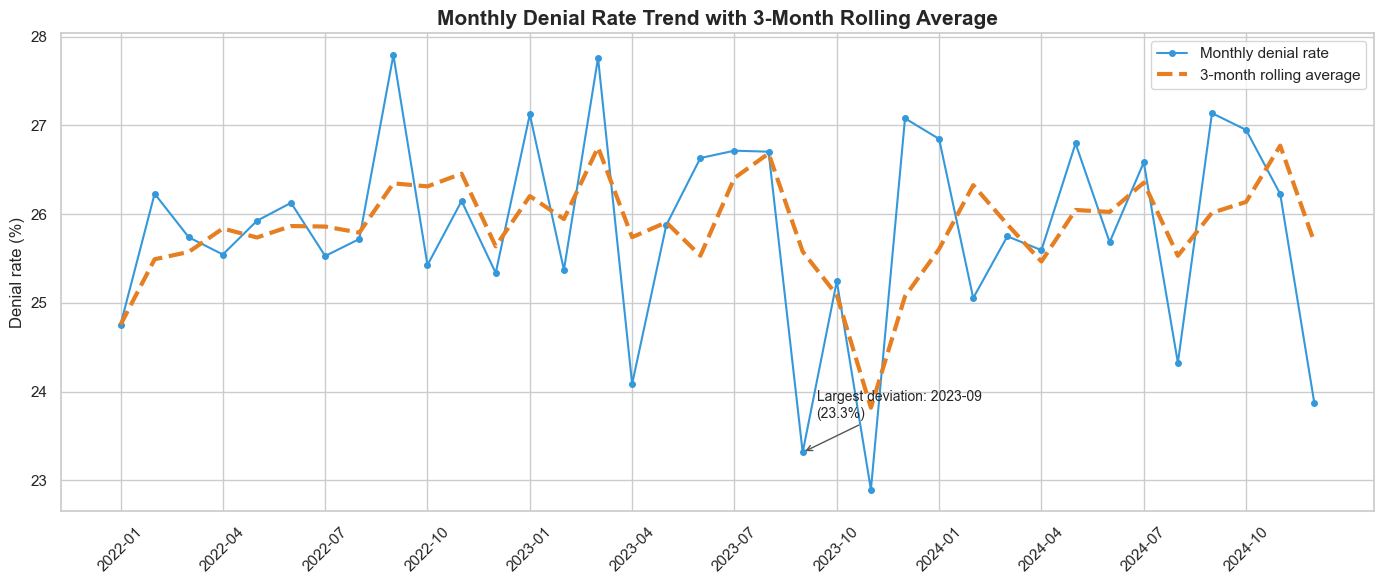

In [11]:
monthly = df.groupby('year_month')['denial_flag'].agg(['mean', 'size'])
monthly['rolling_3mo'] = monthly['mean'].rolling(3, min_periods=1).mean()

fig, ax = plt.subplots()
ax.plot(monthly.index, monthly['mean'] * 100, marker='o', ms=4,
        color='#3498db', lw=1.5, label='Monthly denial rate')
ax.plot(monthly.index, monthly['rolling_3mo'] * 100, color='#e67e22',
        lw=3, ls='--', label='3-month rolling average')

# Annotate the biggest deviation from the rolling average
dev = (monthly['mean'] - monthly['rolling_3mo']).abs()
spike = dev.idxmax()
ax.annotate(f"Largest deviation: {spike}\n({monthly.loc[spike, 'mean']:.1%})",
            xy=(list(monthly.index).index(spike), monthly.loc[spike, 'mean'] * 100),
            xytext=(10, 25), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='#555'), fontsize=10)

ax.set_title('Monthly Denial Rate Trend with 3-Month Rolling Average')
ax.set_ylabel('Denial rate (%)')
ax.set_xticks(range(0, len(monthly), 3))
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## 10. Geographic Analysis

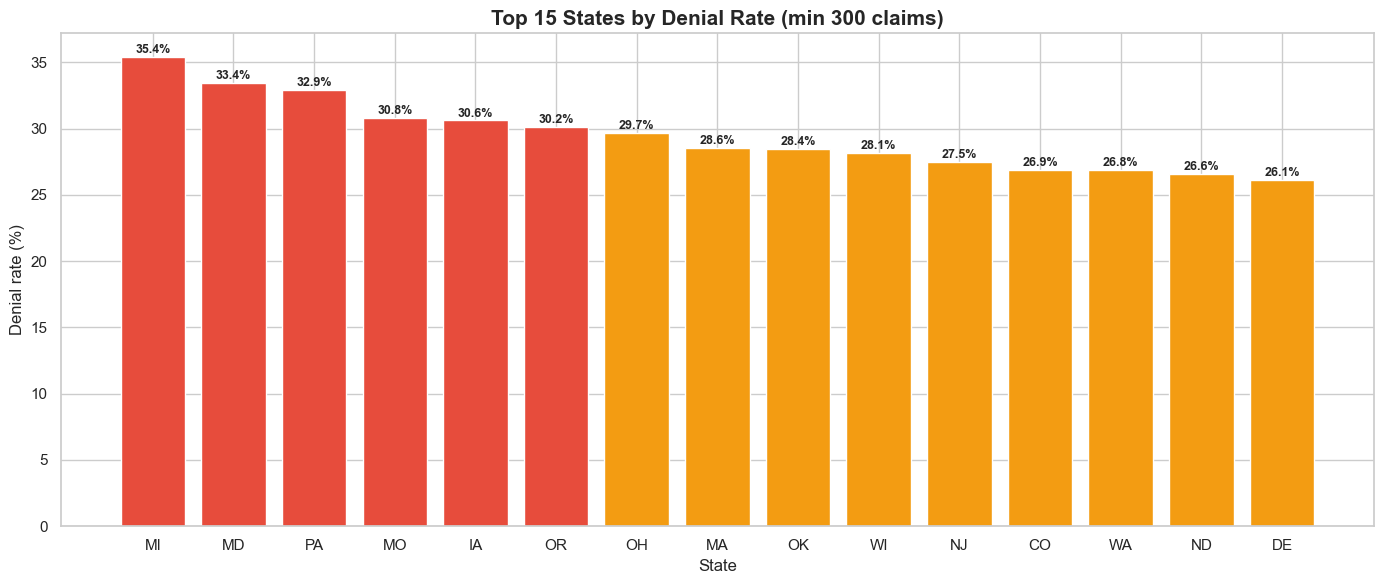

In [12]:
state_stats = df.groupby('state')['denial_flag'].agg(['mean', 'size'])
state_stats = state_stats[state_stats['size'] >= 300]  # stable rates only
top15 = state_stats.sort_values('mean', ascending=False).head(15)

fig, ax = plt.subplots()
bars = ax.bar(top15.index, top15['mean'] * 100,
              color=[rate_color(r) for r in top15['mean']])
for bar, r in zip(bars, top15['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{r:.1%}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Top 15 States by Denial Rate (min 300 claims)')
ax.set_ylabel('Denial rate (%)')
ax.set_xlabel('State')
plt.tight_layout()
plt.show()

## 11. Claim Amount Analysis

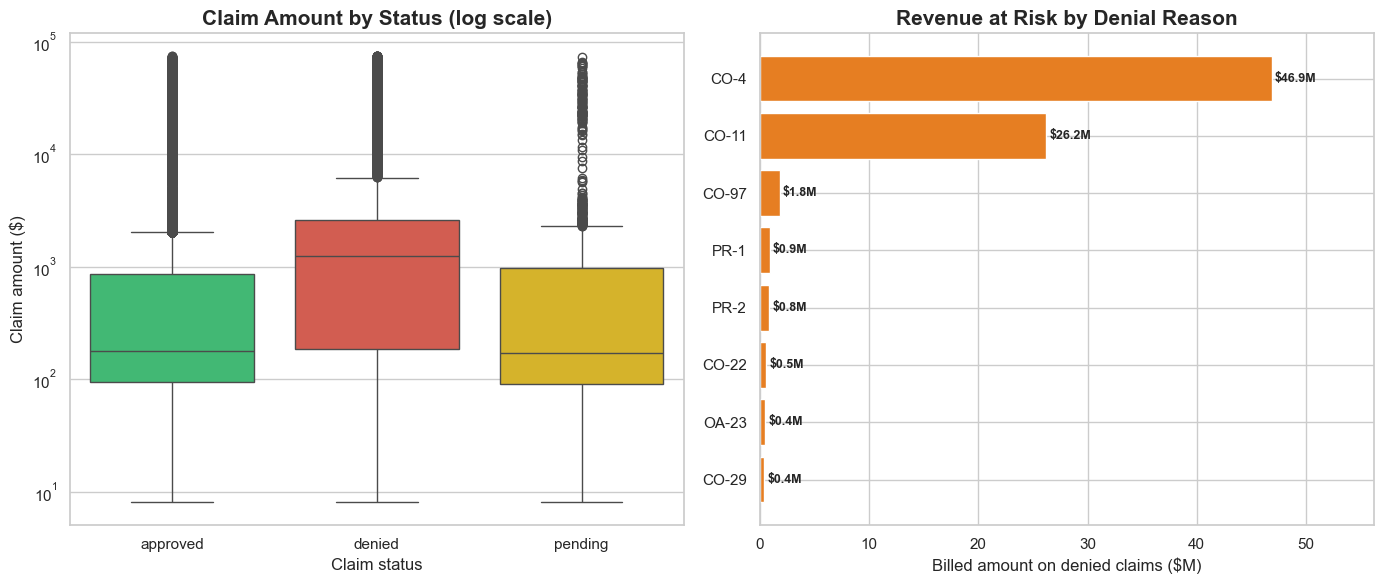

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot on log scale (claim amounts span $8 to $75k)
sns.boxplot(data=df, x='claim_status', y='claim_amount', hue='claim_status',
            palette={'approved': '#2ecc71', 'denied': '#e74c3c', 'pending': '#f1c40f'},
            ax=axes[0], legend=False)
axes[0].set_yscale('log')
axes[0].set_title('Claim Amount by Status (log scale)')
axes[0].set_xlabel('Claim status'); axes[0].set_ylabel('Claim amount ($)')

# Revenue at risk by denial reason
rar = (df[df['denial_flag'] == 1].groupby('denial_reason_code')['claim_amount']
       .sum().sort_values())
axes[1].barh(rar.index, rar.values / 1e6, color='#e67e22')
for i, v in enumerate(rar.values):
    axes[1].text(v / 1e6 + 0.3, i, f'${v/1e6:.1f}M', va='center', fontsize=9, fontweight='bold')
axes[1].set_title('Revenue at Risk by Denial Reason')
axes[1].set_xlabel('Billed amount on denied claims ($M)')
axes[1].set_xlim(0, rar.max() / 1e6 * 1.2)
plt.tight_layout()
plt.show()

## 12. Correlation Heatmap

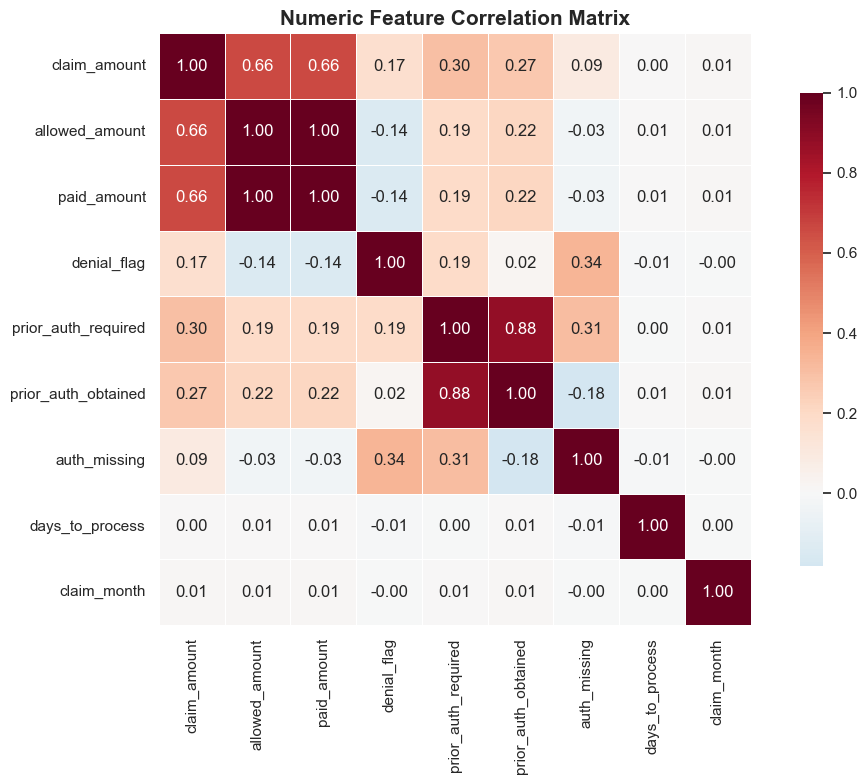

In [14]:
num = df[['claim_amount', 'allowed_amount', 'paid_amount', 'denial_flag']].copy()
num['prior_auth_required'] = df['prior_auth_required'].astype(int)
num['prior_auth_obtained'] = df['prior_auth_obtained'].astype(int)
num['auth_missing'] = (df['prior_auth_required'] & ~df['prior_auth_obtained']).astype(int)
num['days_to_process'] = (df['claim_date'] - df['service_date']).dt.days
num['claim_month'] = df['claim_date'].dt.month

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(num.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Numeric Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 13. Key Insights Summary

1. **Prior authorization is the dominant lever** — claims requiring auth without obtaining it deny at **~84%** vs **~27%** when obtained (a 3x multiplier). An automated pre-submission auth check would eliminate the largest preventable loss bucket.
2. **Payer mix drives baseline risk** — self-pay (**~40%**) and Medicaid (**~35%**) deny at 2.3–2.7x the Medicare rate (**~15%**); revenue forecasting should be payer-weighted, not flat.
3. **Coding integrity is the second lever** — CO-4 (modifier/procedure inconsistency) and CO-11 (diagnosis/procedure mismatch) together account for **over half of all denials**, pointing to claim-scrubber rule gaps.
4. **~$78M in billed charges sat in denied status** over 36 months (~$26M/year); even a 50% first-pass recovery on auth + coding denials is an eight-figure annual win.
5. **Denial rates are flat month-over-month** (3-month rolling average stays within a narrow band) — losses are systemic and process-driven, which is exactly what makes them fixable and worth modeling: the XGBoost scorer reaches **AUC 0.83** on these features.